# Skip edges

`parse_edgelist()` layers a DAG and puts **adjacent** edges (depth
gap exactly 1) into `GraphSpec.masks`. An original edge whose
endpoints are more than one layer apart is a **skip**. Skips are
**not** written into the masks and are **not** expanded into dummy
neurons.

You keep the source activation in ordinary Python memory and add it
when the target layer is computed. That residual is part of your
`nn.Module.forward()`, not a compiler pass. `MaskedLinear` never
stores other layers' activations.

This page is the contract for that split. The
[Getting started](../getting-started/) notebook uses a graph with no
skips; the pattern here is what you add when the edgelist jumps a
layer.


## Why skips need an explicit residual

A chain such as `A -> H -> C` is naturally layer-wise: each
`MaskedLinear` maps one `layer_nodes` list to the next.

A direct edge `A -> C` is still a valid DAG edge, but `C` sits two
layers below `A`. A strictly adjacent hop from layer 1 (`H`) to
layer 2 (`C`) has no column for `A`.

`kpnn2` does not insert dummy neurons to turn a skip into a chain
of adjacent hops. There is no identity overwrite and no generated
node name.

![Skip residual](../figures/skip_residual.svg)

**Figure 1.** Adjacent edges `A -> H` and `H -> C` are ones in
`spec.masks`. The skip `A -> C` stays out of the masks. In
`forward()`, keep the layer-0 tensor and add `w * A` into `C`.


> **What you will not see**
>
> `spec.masks` never contain skip edges. Attribution tables from
> `map_node_attributions()` only use original `layer_nodes` names.
> If a skip matters for the prediction, its effect appears on the
> **named target node**, not on a dummy channel.


In [1]:
import random

import pandas as pd
import torch
import torch.nn.functional as F
from graphviz import Digraph
from torch import nn

import kpnn2 as k2

random.seed(42)
torch.manual_seed(42)
pass

## What `parse_edgelist()` records

The toy graph is a chain plus one skip `A -> C`.


In [2]:
edgelist = pd.DataFrame(
    {
        "source": ["A", "H", "A"],
        "target": ["H", "C", "C"],
    }
)
edgelist

,source,target
0,A,H
1,H,C
2,A,C


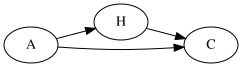

In [3]:
dot = Digraph()
dot.attr(rankdir="LR")
for name in ["A", "H", "C"]:
    dot.node(name, name)
for row in edgelist.itertuples(index=False):
    dot.edge(str(row.source), str(row.target))
dot

In [4]:
spec = k2.parse_edgelist(edgelist)
spec.layer_nodes

(('A',), ('H',), ('C',))

In [5]:
[tuple(mask.shape) for mask in spec.masks]

[(1, 1), (1, 1)]

In [6]:
spec.masks[0].tolist(), spec.masks[1].tolist()

([[1.0]], [[1.0]])

Each mask is `(n_{i+1}, n_i)` with a `1.0` only for an original
edge of depth gap 1. Both hops here are `1 x 1` ones: `A -> H` and
`H -> C`. The skip is absent. The total number of ones across
masks is 2, not 3.


In [7]:
int(sum(mask.sum().item() for mask in spec.masks))

2

In [8]:
skip = spec.skips[0]
(
    skip.source,
    skip.target,
    skip.source_layer,
    skip.target_layer,
    skip.source_index,
    skip.target_index,
)

('A', 'C', 0, 2, 0, 0)

`Skip` fields are indices into `spec.layer_nodes`, so you can slice
saved tensors without searching names at runtime:

| Field | In this graph |
| --- | --- |
| `source`, `target` | `"A"`, `"C"` |
| `source_layer`, `target_layer` | `0`, `2` (gap `> 1`) |
| `source_index`, `target_index` | `0`, `0` |


## Wire the skip in `forward()`

Keep a dict of layer tensors. When hop `i` produces layer
`i + 1`, apply every skip whose `target_layer` is `i + 1`: add a
learnable scalar times the saved source column into the target
index.

`MaskedLinear` is only the adjacent hop. The residual is your code.


In [9]:
class SkipResidualNet(nn.Module):
    def __init__(self, spec):
        super().__init__()
        self.spec = spec
        self.layer0 = k2.MaskedLinear(
            spec.masks[0],
            bias=False,
        )
        self.layer1 = k2.MaskedLinear(
            spec.masks[1],
            bias=False,
        )
        self.w_skip = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        saved = {0: x}
        hidden = F.relu(self.layer0(x))
        saved[1] = hidden
        out = self.layer1(hidden)
        for skip in self.spec.skips:
            source = saved[skip.source_layer][
                :,
                skip.source_index,
            ]
            addition = torch.zeros_like(out)
            addition[:, skip.target_index] = self.w_skip * source
            out = out + addition
        return out


model = SkipResidualNet(spec)
model

SkipResidualNet(
  (layer0): MaskedLinear()
  (layer1): MaskedLinear()
)

Pin adjacent weights to `1` and the skip scalar to `0.3`. Then the
output is the adjacent path plus `0.3 * A`, not a pseudo-node
chain. ReLU on `H` still applies only on the adjacent path.


In [10]:
x = torch.tensor(
    [
        [2.0],
        [-1.0],
    ],
    dtype=torch.float32,
)

with torch.no_grad():
    model.layer0.raw_weight.fill_(1.0)
    model.layer1.raw_weight.fill_(1.0)
    model.w_skip.fill_(0.3)

hidden = F.relu(model.layer0(x))
adjacent = model.layer1(hidden)
y = model(x)

hidden.tolist(), adjacent.tolist(), y.tolist()

([[2.0], [0.0]],
 [[2.0], [0.0]],
 [[2.5999999046325684], [-0.30000001192092896]])

For `A = 2`, `H = relu(2) = 2` and `C = 2 + 0.3 * 2 = 2.6`. For
`A = -1`, the adjacent path is zero after ReLU, but the skip still
adds `0.3 * (-1)`. Setting `w_skip` to `0` recovers the adjacent
path alone.


In [11]:
with torch.no_grad():
    model.w_skip.fill_(0.0)
model(x).tolist()

[[2.0], [0.0]]

## Several skips

If more than one skip exists, keep every layer tensor you might
need (a dict keyed by layer index, as above). When you finish layer
`t`, loop `spec.skips` and apply those with `target_layer == t`.
Each skip can have its own scalar, or any module you choose; kpnn2
does not pick the parameterization.

Longer jumps (`source_layer` much smaller than `target_layer`) use
the same rule: the source activation is still in `saved`, so you do
not insert intermediate dummy units.


## Interpretation

`map_node_attributions()` labels a layer tensor as xarray with
`spec.layer_nodes[layer]` on the `node` axis. Those names are
the original edgelist nodes. A skip residual changes the target unit's value; Captum (or
any other method) attributes that named unit, not a hidden carrier.

There is no `pseudo_node_*` in the spec, in the masks, or in
attribution tables. For the mapper itself, see
[Mapping attributions](../map-node-attributions/).
